# Go2 EEG 解码演示 2：MLP 神经网络

本 Notebook 使用 `data/go2_eeg_preprocessed.npz` 作为输入，演示如何用 MLP（Multi-Layer Perceptron）完成 `L/S/R` 三分类 EEG 解码。

## 1. 导入依赖和读取路径

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
        break
plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "go2_eeg_preprocessed.npz").exists():
            return candidate
    raise FileNotFoundError("无法找到 data/go2_eeg_preprocessed.npz")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"
# print(f"数据文件: {DATA_PATH}")

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"device: {device}")


PyTorch: 1.12.0
device: cuda


## 2. 读取预处理后的特征

MLP 接收二维输入，因此使用 `X_train_flat` 和 `X_test_flat`。这些特征已经在预处理阶段按训练集通道统计量做过标准化。

In [2]:
data = np.load(DATA_PATH, allow_pickle=True)

X_train = data["X_train_flat"].astype(np.float32)
X_test = data["X_test_flat"].astype(np.float32)
y_train = data["y_train"].astype(np.int64)
y_test = data["y_test"].astype(np.int64)
label_classes = data["label_classes"].astype(str)

n_features = X_train.shape[1]
n_classes = len(label_classes)

print("数据形状")
print(f"- X_train: {X_train.shape}")
print(f"- X_test: {X_test.shape}")
print(f"- y_train: {y_train.shape}")
print(f"- y_test: {y_test.shape}")
print()
print("标签映射")
for idx, name in enumerate(label_classes):
    print(f"- {idx}: {name}")


数据形状
- X_train: (141, 9984)
- X_test: (36, 9984)
- y_train: (141,)
- y_test: (36,)

标签映射
- 0: L
- 1: R
- 2: S


## 3. 定义 PCA + MLP 解码流程

训练样本只有 141 个，而 flatten 后的 EEG 特征有 9984 维。直接训练 MLP 很容易过拟合，因此这里先在训练数据上拟合 `StandardScaler + PCA`，把特征压缩到 10 维，再训练一个小型 MLP。

在交叉验证中，scaler 和 PCA 都只在每个 fold 的训练折上拟合。

In [3]:
PCA_COMPONENTS = 10
HIDDEN_UNITS = (32,)
DROPOUT = 0.0
EPOCHS = 80
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3


class EEGMLP(nn.Module):
    def __init__(self, n_features: int, n_classes: int, hidden_units=(32,), dropout=0.0):
        super().__init__()
        layers = []
        in_features = n_features
        for hidden in hidden_units:
            layers.extend([
                nn.Linear(in_features, hidden),
                nn.ReLU(),
            ])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden
        layers.append(nn.Linear(in_features, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_loader(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def fit_feature_transform(X_fit, X_apply, n_components=PCA_COMPONENTS):
    scaler = StandardScaler()
    X_fit_scaled = scaler.fit_transform(X_fit)
    X_apply_scaled = scaler.transform(X_apply)

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_fit_pca = pca.fit_transform(X_fit_scaled).astype(np.float32)
    X_apply_pca = pca.transform(X_apply_scaled).astype(np.float32)
    return X_fit_pca, X_apply_pca, scaler, pca


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            total += len(yb)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            targets.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return total_loss / total, accuracy_score(targets, preds), preds, targets


def train_mlp(X_tr, y_tr, X_val=None, y_val=None, epochs=EPOCHS, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = EEGMLP(
        n_features=X_tr.shape[1],
        n_classes=n_classes,
        hidden_units=HIDDEN_UNITS,
        dropout=DROPOUT,
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    train_loader = make_loader(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = None if X_val is None else make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        train_preds = []
        train_targets = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(yb)
            total += len(yb)
            train_preds.append(logits.argmax(dim=1).detach().cpu().numpy())
            train_targets.append(yb.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = accuracy_score(np.concatenate(train_targets), np.concatenate(train_preds))
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if val_loader is not None:
            val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

    return model, history


print("MLP baseline 配置")
print(f"- PCA components: {PCA_COMPONENTS}")
print(f"- hidden units: {HIDDEN_UNITS}")
print(f"- dropout: {DROPOUT}")
print(f"- epochs: {EPOCHS}")
print(f"- device: {device}")

MLP baseline 配置
- PCA components: 10
- hidden units: (32,)
- dropout: 0.0
- epochs: 80
- device: cuda


## 4. 训练集内部交叉验证

使用 Stratified K-Fold 在训练集内部做交叉验证。每个 fold 都单独拟合 scaler/PCA，再训练 MLP，并记录每个 epoch 的训练/验证 loss。

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_histories = []
fold_val_acc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"Fold {fold}")
    X_tr_raw, X_val_raw = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    X_tr, X_val, scaler, pca = fit_feature_transform(X_tr_raw, X_val_raw, n_components=PCA_COMPONENTS)
    _, history = train_mlp(X_tr, y_tr, X_val, y_val, epochs=EPOCHS, seed=RANDOM_STATE + fold)

    fold_histories.append(history)
    fold_val_acc.append(history["val_acc"][-1])
    print(
        f"- final train_loss={history['train_loss'][-1]:.4f}, "
        f"val_loss={history['val_loss'][-1]:.4f}, val_acc={history['val_acc'][-1]:.3f}"
    )

print()
print("交叉验证验证集准确率")
print(f"- mean: {np.mean(fold_val_acc):.3f}")
print(f"- std: {np.std(fold_val_acc):.3f}")

Fold 1


- final train_loss=0.5944, val_loss=1.2598, val_acc=0.448
Fold 2
- final train_loss=0.5431, val_loss=1.1245, val_acc=0.500
Fold 3
- final train_loss=0.5268, val_loss=1.4017, val_acc=0.429
Fold 4
- final train_loss=0.5416, val_loss=2.0399, val_acc=0.214
Fold 5
- final train_loss=0.5083, val_loss=1.3853, val_acc=0.429

交叉验证验证集准确率
- mean: 0.404
- std: 0.098


## 5. 交叉验证平均训练/验证损失曲线

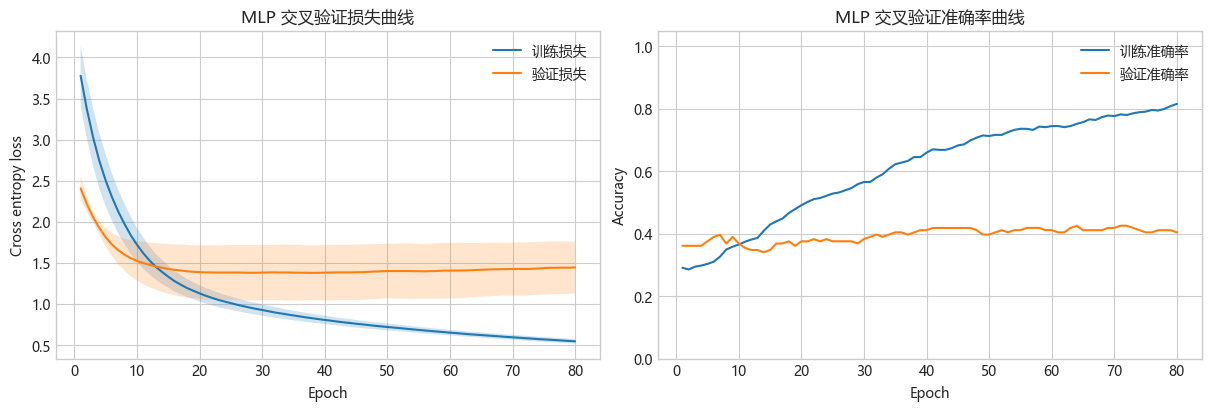

In [5]:
epochs = np.arange(1, EPOCHS + 1)
train_loss = np.asarray([h["train_loss"] for h in fold_histories])
val_loss = np.asarray([h["val_loss"] for h in fold_histories])
train_acc = np.asarray([h["train_acc"] for h in fold_histories])
val_acc = np.asarray([h["val_acc"] for h in fold_histories])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(epochs, train_loss.mean(axis=0), label="训练损失")
axes[0].fill_between(epochs, train_loss.mean(axis=0) - train_loss.std(axis=0), train_loss.mean(axis=0) + train_loss.std(axis=0), alpha=0.2)
axes[0].plot(epochs, val_loss.mean(axis=0), label="验证损失")
axes[0].fill_between(epochs, val_loss.mean(axis=0) - val_loss.std(axis=0), val_loss.mean(axis=0) + val_loss.std(axis=0), alpha=0.2)
axes[0].set_title("MLP 交叉验证损失曲线")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross entropy loss")
axes[0].legend()

axes[1].plot(epochs, train_acc.mean(axis=0), label="训练准确率")
axes[1].plot(epochs, val_acc.mean(axis=0), label="验证准确率")
axes[1].set_title("MLP 交叉验证准确率曲线")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.show()


## 6. 使用完整训练集训练最终模型

交叉验证用于估计训练过程和泛化表现。最终测试集评估前，scaler、PCA 和 MLP 都在完整训练集上重新拟合，不再额外划走 20% 训练样本。

In [6]:
X_train_pca, X_test_pca, final_scaler, final_pca = fit_feature_transform(
    X_train,
    X_test,
    n_components=PCA_COMPONENTS,
)

final_model, final_history = train_mlp(
    X_train_pca,
    y_train,
    X_val=None,
    y_val=None,
    epochs=EPOCHS,
    seed=123,
)

print("最终模型训练完成")
print(f"- PCA 累计可解释方差: {final_pca.explained_variance_ratio_.sum():.3f}")
print(f"- 最后一轮训练 loss: {final_history['train_loss'][-1]:.4f}")
print(f"- 最后一轮训练 acc: {final_history['train_acc'][-1]:.3f}")

最终模型训练完成
- PCA 累计可解释方差: 0.324
- 最后一轮训练 loss: 0.5298
- 最后一轮训练 acc: 0.837


## 7. 最终模型训练曲线

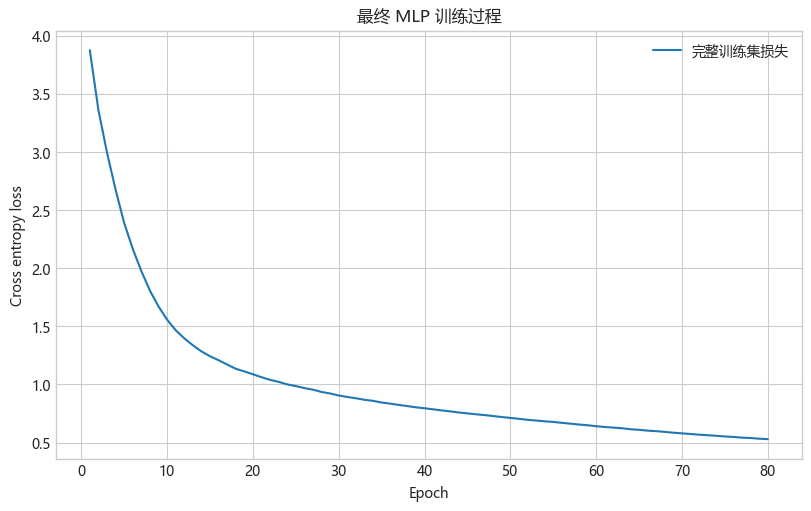

In [7]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(epochs, final_history["train_loss"], label="完整训练集损失")
ax.set_title("最终 MLP 训练过程")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross entropy loss")
ax.legend()
plt.show()

## 8. 在测试集上解码并计算三分类准确率

Loss: 1.3780
宏平均准确率: 0.6296
加权准确率: 0.6296
宏平均精确率: 0.4449
加权精确率: 0.4449
宏平均召回率: 0.4444
加权召回率: 0.4444
宏平均 F1: 0.4408
加权 F1: 0.4408

分类报告
              precision    recall  f1-score   support

           L       0.43      0.50      0.46        12
           R       0.46      0.50      0.48        12
           S       0.44      0.33      0.38        12

    accuracy                           0.44        36
   macro avg       0.44      0.44      0.44        36
weighted avg       0.44      0.44      0.44        36



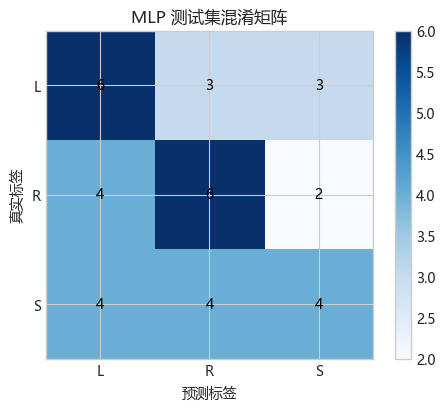

In [8]:
test_loader = make_loader(X_test_pca, y_test, batch_size=BATCH_SIZE, shuffle=False)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, test_pred, test_true = evaluate(final_model, test_loader, criterion)

cm = confusion_matrix(test_true, test_pred, labels=np.arange(n_classes))
support = cm.sum(axis=1)
per_class_accuracy = []
for class_idx in range(n_classes):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    per_class_accuracy.append((tp + tn) / cm.sum())
per_class_accuracy = np.asarray(per_class_accuracy)

test_accuracy_macro = per_class_accuracy.mean()
test_accuracy_weighted = np.average(per_class_accuracy, weights=support)
test_precision_macro = precision_score(test_true, test_pred, average="macro", zero_division=0)
test_precision_weighted = precision_score(test_true, test_pred, average="weighted", zero_division=0)
test_recall_macro = recall_score(test_true, test_pred, average="macro", zero_division=0)
test_recall_weighted = recall_score(test_true, test_pred, average="weighted", zero_division=0)
test_f1_macro = f1_score(test_true, test_pred, average="macro", zero_division=0)
test_f1_weighted = f1_score(test_true, test_pred, average="weighted", zero_division=0)

print(f"Loss: {test_loss:.4f}")
print(f"宏平均准确率: {test_accuracy_macro:.4f}")
print(f"加权准确率: {test_accuracy_weighted:.4f}")
print(f"宏平均精确率: {test_precision_macro:.4f}")
print(f"加权精确率: {test_precision_weighted:.4f}")
print(f"宏平均召回率: {test_recall_macro:.4f}")
print(f"加权召回率: {test_recall_weighted:.4f}")
print(f"宏平均 F1: {test_f1_macro:.4f}")
print(f"加权 F1: {test_f1_weighted:.4f}")
print()
print("分类报告")
print(classification_report(test_true, test_pred, target_names=label_classes))

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(cm, cmap="Blues")
ax.set_title("MLP 测试集混淆矩阵")
ax.set_xlabel("预测标签")
ax.set_ylabel("真实标签")
ax.set_xticks(np.arange(n_classes), label_classes)
ax.set_yticks(np.arange(n_classes), label_classes)
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.show()
